In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [12]:
df = pd.read_csv('/Users/rachellee/Desktop/projects/covidDataAnalysis/CovidDeaths.csv')
df = df[df['continent'].notna() & (df['continent'] != '')]
df.head()

,iso_code,continent,location,date,population,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,...,new_deaths_smoothed_per_million,reproduction_rate,icu_patients,icu_patients_per_million,hosp_patients,hosp_patients_per_million,weekly_icu_admissions,weekly_icu_admissions_per_million,weekly_hosp_admissions,weekly_hosp_admissions_per_million
0,AFG,Asia,Afghanistan,2/24/20,38928341.0,1.0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2/25/20,38928341.0,1.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2/26/20,38928341.0,1.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2/27/20,38928341.0,1.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2/28/20,38928341.0,1.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print(df.shape)
print(df.describe())

(81060, 26)
         population   total_cases      new_cases  new_cases_smoothed  \
count  8.096000e+04  7.896600e+04   78959.000000        78011.000000   
mean   4.268106e+07  2.729878e+05    1907.002077         1897.173920   
std    1.544602e+08  1.471945e+06   10349.057053         9910.684528   
min    8.090000e+02  1.000000e+00  -74347.000000        -6223.000000   
25%    2.225728e+06  8.880000e+02       2.000000            6.429000   
50%    9.537642e+06  9.139000e+03      60.000000           74.143000   
75%    3.125544e+07  9.251875e+04     631.000000          658.071500   
max    1.439324e+09  3.234697e+07  401993.000000       364926.857000   

        total_deaths    new_deaths  new_deaths_smoothed  \
count   69469.000000  69468.000000         78011.000000   
mean     7578.109401     45.779438            40.214993   
std     31979.984778    197.494553           173.508619   
min         1.000000  -1918.000000          -232.143000   
25%        42.000000      0.000000          

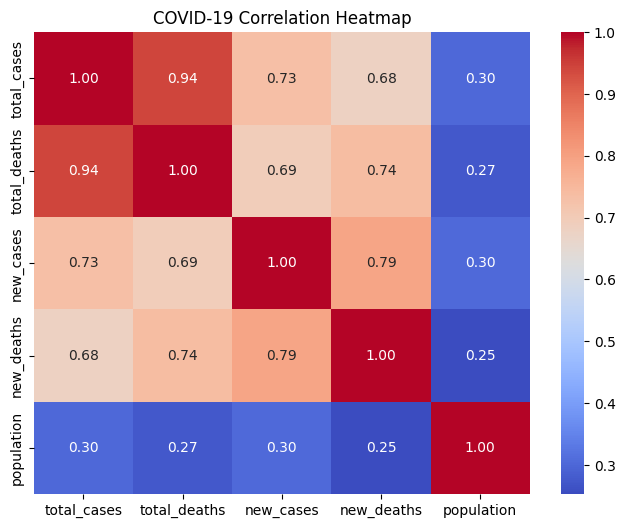

In [14]:
cols = ['total_cases', 'total_deaths', 'new_cases', 'new_deaths', 'population']
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('COVID-19 Correlation Heatmap')
plt.show()

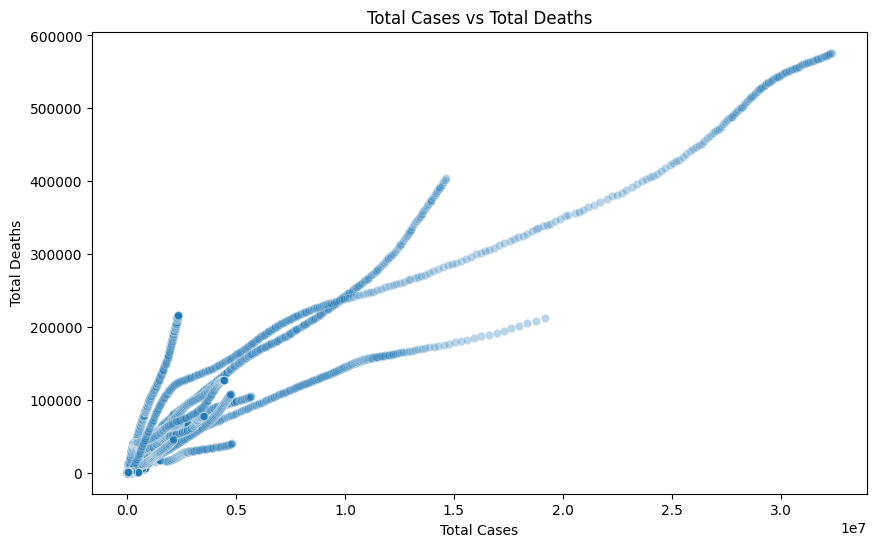

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_cases', y='total_deaths', alpha=0.3)
plt.title('Total Cases vs Total Deaths')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.show()

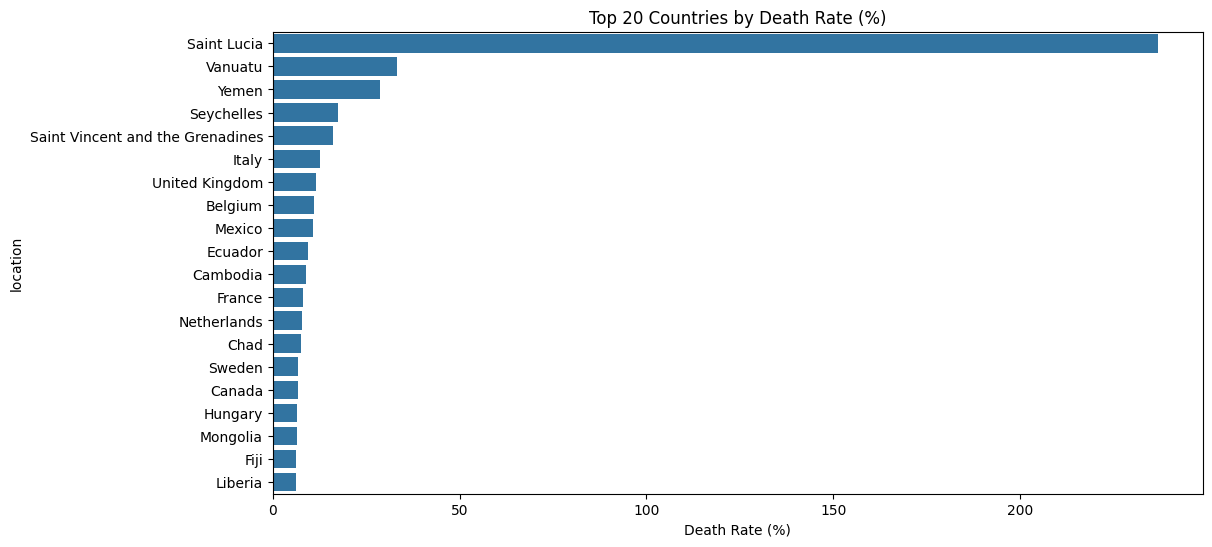

In [16]:
latest = df.sort_values('date').groupby('location').last().reset_index()
latest['death_rate'] = latest['total_deaths'] / latest['total_cases'] * 100

top20 = latest.nlargest(20, 'death_rate')

plt.figure(figsize=(12, 6))
sns.barplot(data=top20, x='death_rate', y='location')
plt.title('Top 20 Countries by Death Rate (%)')
plt.xlabel('Death Rate (%)')
plt.show()